This is designed to extract data from previous experiment runs for future reference.

In [1]:
import h5py
from datetime import datetime
from sipyco import pyon
import sys
# add repository path
sys.path.append("../")

from repository.imaging.processor import AbsImage, AbsImageSettings

class HDF5DataExtractor:
    def __init__(self, filename):
        self.filename = filename
        with h5py.File(filename, "r") as f:
            self._h5_data = self._hdf5_to_dict(f)
            self.expid = pyon.decode(f["expid"][()])
            self.devarg_overrides = self.expid.get("devarg_overrides")
            self.log_level = self.expid.get("log_level")
            self.exp_file = self.expid.get("file")
            self.name = self.expid.get("class_name")
            self.args = self.expid.get("arguments")
            self.repo_rev = self.expid.get("repo_rev")

        self.rid = self._h5_data["rid"]
        self.artiq_version = self._h5_data["artiq_version"]
        self.start_time = datetime.fromtimestamp(self._h5_data["start_time"])
        self.datasets = self._h5_data["datasets"]

        try:
            self._run_absimg()
        except Exception as e:
            print(f"Failed to process AbsImage data. Check that the required datasets are present and correctly formatted. Error: {e}")
            self.absimg = None

    def _run_absimg(self):
        self.absimg = AbsImage(
            data=self.datasets["Images.absorption.TOF"],
            ref=self.datasets["Images.absorption.REF"],
            bg=self.datasets["Images.absorption.BG"],
            settings = AbsImageSettings.from_dataset(self.datasets["Images.absorption.settings"])
        )


    def _hdf5_to_dict(self, obj):
        out = {}
        if isinstance(obj, h5py.Group):
            for key, item in obj.items():
                out[key] = self._hdf5_to_dict(item)
        elif isinstance(obj, h5py.Dataset):
            data = obj[()]
            # Convert bytes to string if possible
            if isinstance(data, bytes):
                try:
                    data = data.decode()
                except Exception:
                    pass
            out = data
        return out

    def get_args(self, print_non_defaults=False):
        # Extract the run's parameters from the HDF5 file which don't match their defaults.
        vals = {}

        for k, v in self.args.items():
            if k == "ndscan_params":
                params = pyon.decode(self.args["ndscan_params"])
                overrides = params["overrides"]
                for k, v in overrides.items():
                    spec = params["schemata"][k]["spec"]
                    val = v[0]["value"]
                    default = type(val)(params["schemata"][k]["default"])
                    if print_non_defaults:
                        if val != default:
                            print(f"{k}: {val} (default: {default})")
                    if isinstance(val, (int, float)):
                        vals[k] = [val,[val / spec.get("scale", 1), spec.get("unit", "")]]
                    else:
                        vals[k] = [val, ""]
            else:
                vals[k] = [v, ""]
        return vals
    
    def __str__(self):
        # Print the experiment's parameters and metadata in a human-readable format
        return f"{self.name} [{self.filename}]\n\trid {self.rid}\n\t{self.start_time.strftime('%H:%M:%S %Y-%m-%d')}\n\tArtiq {self.artiq_version}"



In [ ]:
from ndscan import results


# filename = (
#     "/storage/Artiq_result_files/results/2026-06-12/12/000024341-AbsorptionImageExpFrag.h5"
# )

filename = (
    "/home/ae19663/artiq/results/2026-06-17/17/000024676-AbsorptionImageExpFrag.h5"
)
# filename = ("/home/ae19663/artiq/results/2026-06-15/17/000024581-analysis_result.h5")
run = HDF5DataExtractor(filename)
keys = run.datasets.keys()
_ = run.absimg.plot()

Selected RID: 25942 from ['25942']
Dataset keys: ['Images.absorption.BG', 'Images.absorption.REF', 'Images.absorption.TOF', 'Images.absorption.expansion_time', 'Images.absorption.settings', 'Images.absorption.timestamp', 'ndscan.rid_25942.analysis_result.Expansion_time_unique', 'ndscan.rid_25942.analysis_result.diam_0_x', 'ndscan.rid_25942.analysis_result.diam_0_x_err', 'ndscan.rid_25942.analysis_result.diam_0_y', 'ndscan.rid_25942.analysis_result.diam_0_y_err', 'ndscan.rid_25942.analysis_result.diam_fit_x', 'ndscan.rid_25942.analysis_result.diam_fit_y', 'ndscan.rid_25942.analysis_result.fit_time_x', 'ndscan.rid_25942.analysis_result.fit_time_y', 'ndscan.rid_25942.analysis_result.mean_sigma_x', 'ndscan.rid_25942.analysis_result.mean_sigma_y', 'ndscan.rid_25942.analysis_result.pixel_calibration_fit', 'ndscan.rid_25942.analysis_result.pixel_number', 'ndscan.rid_25942.analysis_result.pixel_number_err', 'ndscan.rid_25942.analysis_result.pixel_size', 'ndscan.rid_25942.analysis_result.pixel_

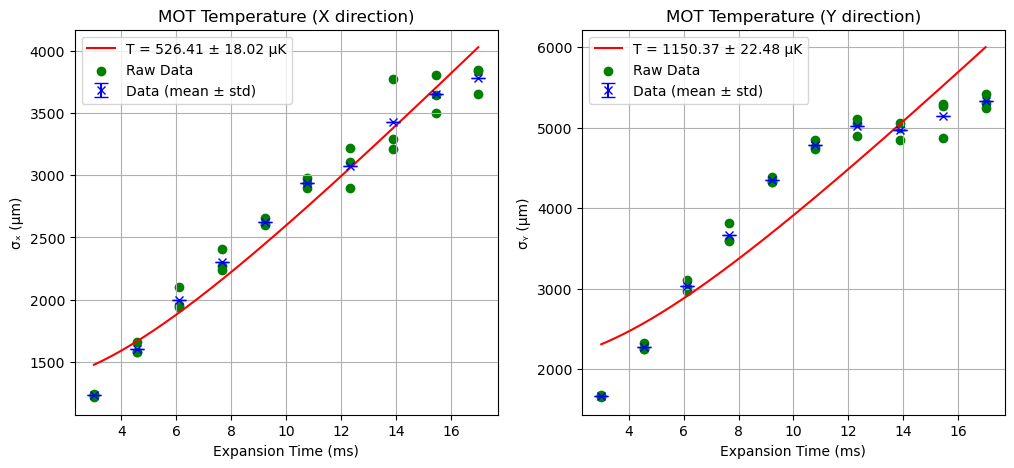

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data from the analysis result 
filename_analysis = (
    "/home/ae19663/artiq/results/2026-07-01/12/000025942-AnalysisResultExpFrag.h5"
)
run = HDF5DataExtractor(filename_analysis)
keys = run.datasets.keys()

# find ones with ndscan.rid_NUM.source_id
rid_keys = [
    key.split(".")[1][4:]
    for key in keys
    if key.startswith("ndscan.rid_") and key.endswith(".source_id")
]
if rid_keys:
    RID = rid_keys[-1]  # Get the last RID in the list
else:
    raise ValueError("No ndscan datasets found.")
print(f"Selected RID: {RID} from {rid_keys}")
print(f"Dataset keys: {list(keys)})")


# store the sigma values and their errors in a dictionary
direction = ["x", "y"]
# plot the sigma values and their errors for both x and y directions

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i, dir in enumerate(direction):
    raw_points = run.datasets[f"ndscan.rid_{RID}.points.channel_sigma{dir}_mm"]
    raw_times = run.datasets[f"ndscan.rid_{RID}.points.axis_0"]
    sigma = run.datasets[f"ndscan.rid_{RID}.analysis_result.mean_sigma_{dir}"]
    sigma_err = run.datasets[f"ndscan.rid_{RID}.analysis_result.std_sigma_{dir}"]
    expansion_time = run.datasets[f"ndscan.rid_{RID}.analysis_result.Expansion_time_unique"]
    T_fit = run.datasets[f"ndscan.rid_{RID}.analysis_result.temperature_{dir}"]
    T_err = run.datasets[f"ndscan.rid_{RID}.analysis_result.temperature_{dir}_err"]
    t_fit = run.datasets[f"ndscan.rid_{RID}.analysis_result.fit_time_{dir}"]
    d_fit = run.datasets[f"ndscan.rid_{RID}.analysis_result.diam_fit_{dir}"]

    # plot the data
    ax[i].plot(t_fit * 1e3, d_fit *1e3, "r-", label=f"T = {T_fit * 1e6:.2f} ± {T_err * 1e6:.2f} μK")
    ax[i].scatter(
        raw_times * 1e3,
        raw_points * 1e3,
        marker="o",
        color="green",
        label="Raw Data",
    )
    ax[i].errorbar(
        expansion_time * 1e3,
        sigma * 1e6,
        yerr=sigma_err,
        fmt="x",
        label=f"Data (mean ± std)",
        capsize=5,
        color="blue"
    )
    ax[i].set_xlabel("Expansion Time (ms)")
    ylabel = (
                    "σₓ (μm)"
                    if dir == "x"
                    else "σᵧ (μm)"
                    if dir == "y"
                    else "Diameter (μm)")
    ax[i].set_ylabel(ylabel)
    title = (
                    "MOT Temperature (X direction)"
                    if dir == "x"
                    else "MOT Temperature (Y direction)"
                    if dir == "y"
                    else "MOT Temperature Fit"
                )
    ax[i].set_title(title)
    
    ax[i].legend()
    ax[i].grid()
 